In [5]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import os
import wrf_module as wrf
import conf  # Importa tu archivo de configuración base


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from metpy.plots import SkewT,Hodograph
from metpy.units import units
import metpy.calc as mpcalc
def prepare_skewt_hodograph():
    # Create a new figure. The dimensions here give a good aspect ratio
    fig = plt.figure(figsize=(18, 12))
    #add_metpy_logo(fig, 630, 80, size='large')

    # Grid for plots
    skew = SkewT(fig, rotation=45, rect=(0.05,0.05,0.50,0.90))

    # Set the limits of the plot
    skew.ax.set_xlim(-20, 30)
    skew.ax.set_ylim(1050, 100)

    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidths=0.5)
    skew.plot_moist_adiabats(linewidths=0.5)
    skew.plot_mixing_lines(linewidths=0.5)
    
    ax = fig.add_axes([0.48,0.45,0.5,0.5])
    h = Hodograph(ax, component_range=10)
    h.add_grid(increment=20, ls='-', lw=1.5, alpha=0.5)
    h.add_grid(increment=10, ls='--', lw=1, alpha=0.2)

    h.ax.set_box_aspect(1)
    h.ax.set_yticklabels([])
    h.ax.set_xticklabels([])
    h.ax.set_xticks([])
    h.ax.set_yticks([])
    h.ax.set_xlabel(' ')
    h.ax.set_ylabel(' ')
    plt.xticks(np.arange(0, 0, 1))
    plt.yticks(np.arange(0, 0, 1))
    for i in range(10, 120, 10):
       h.ax.annotate(str(i), (i, 0), xytext=(0, 2), textcoords='offset pixels',
                     clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)
    for i in range(10, 120, 10):
       h.ax.annotate(str(i), (0, i), xytext=(0, 2), textcoords='offset pixels',
                     clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)
    return fig, skew, h

def plot_sounding(fig, skew, h, my_data , plot_path , show=False )  :

    
    p=my_data['p'] * units.hPa
    t=my_data['t'] * units.degC
    z=my_data['z'] * units.meter
    #td=my_data['td'] * units.degC
    u=my_data['u'] * units.meter / units.second
    v=my_data['v'] * units.meter / units.second
    #qv = my_data['qv'] * units.gram / units.kilogram
    #td = mpcalc.dewpoint_from_specific_humidity(p,qv)
    td = my_data['td'] * units.degC
    # Plot the data using normal plotting functions, in this case using
    # log scaling in Y, as dictated by the typical meteorological plot
    skew.plot(p , t , 'r')
    skew.plot(p , td , 'g')
    idx100=np.argmin(np.abs(np.array(p) - 100))
    #skew.plot_barbs(p[0:idx100],u[0:idx100],v[0:idx100])

    lcl_pressure, lcl_temperature = mpcalc.lcl(p[0] , t[0] , td[0]  )
    skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black')

    # Calculate full parcel profile and add to plot as black line
    prof = mpcalc.parcel_profile(p , t[0] , td[0] ).to('degC')
    skew.plot(p, prof, 'k', linewidth=2)

    # Shade areas of CAPE and CIN
    skew.shade_cin(p,t,prof,alpha=0.2)
    skew.shade_cape(p,t,prof,alpha=0.2)
    # Good bounds for aspect ratio

    # Create a hodograph
    
    max_speed = round(np.nanmax([np.nanmax(abs(my_data['u'])),np.nanmax(abs(my_data['u']))])/10)*10

    h.plot(my_data['u'],my_data['v'])



    if show :
       plt.show()

    #plt.savefig(fig_name,dpi=dpi)
    #plt.close()

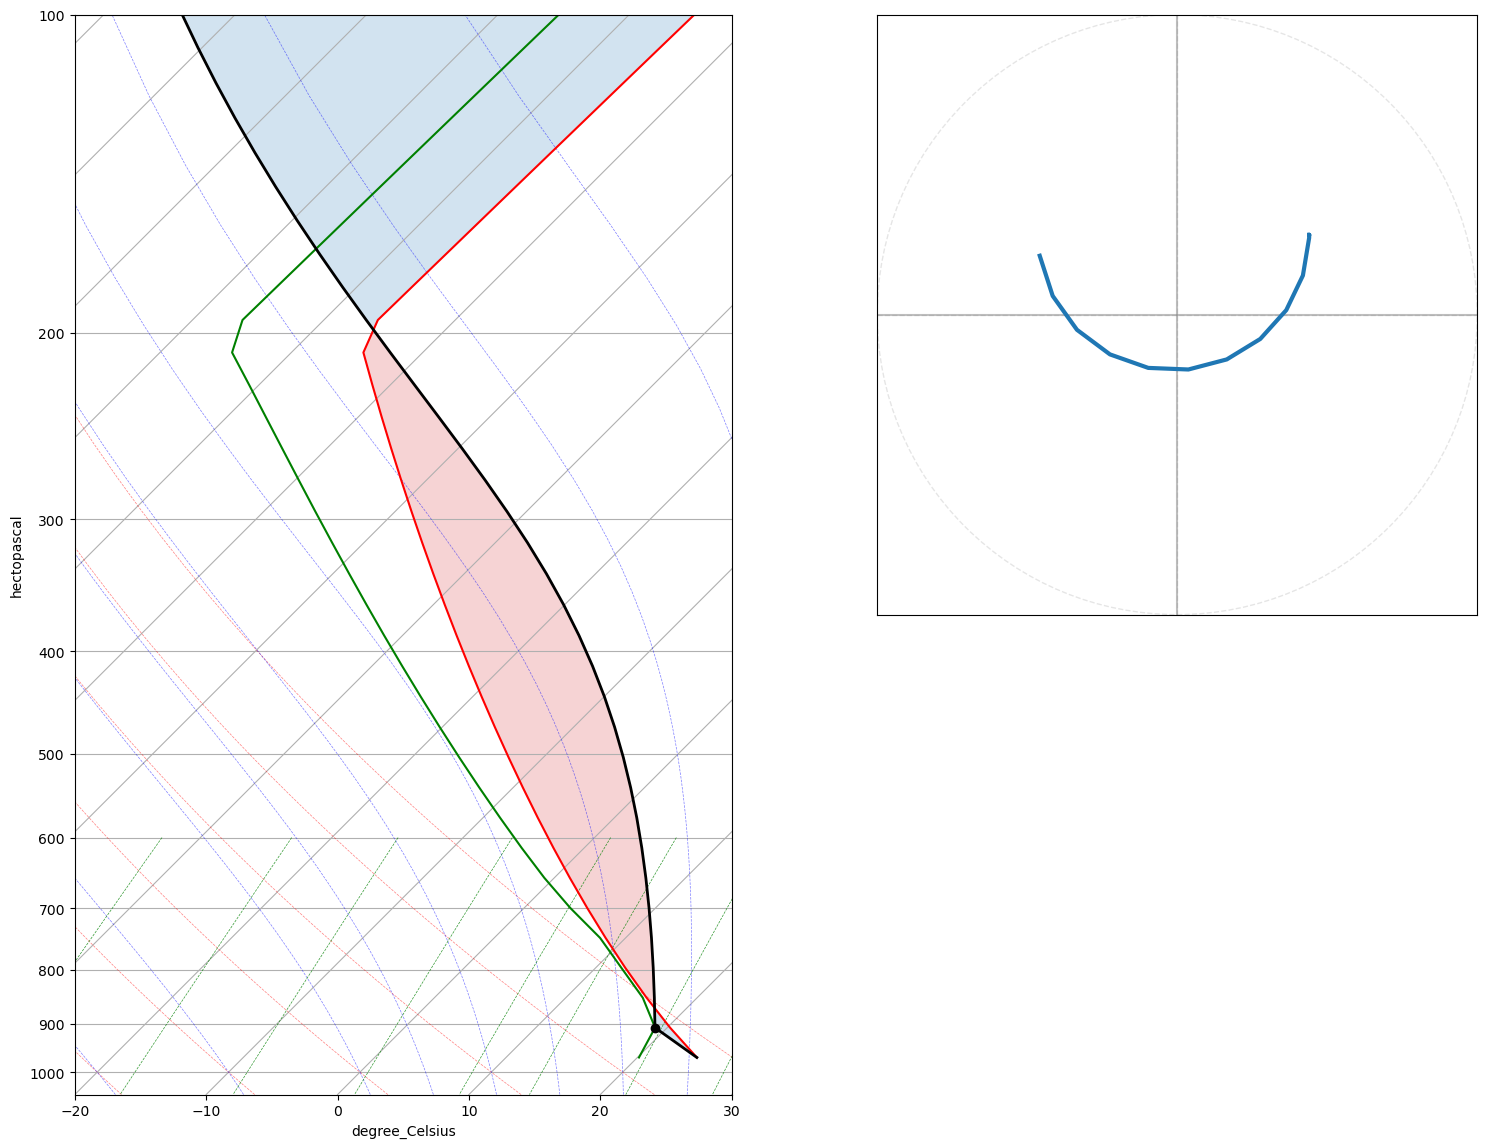

In [15]:
import numpy as np
import matplotlib.pyplot as plt

#load npz
profile='/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/TEST_Multi_8_vars_996/000/profile_000.npz'
data_profile = np.load(profile)

#print(data_profile.keys())
# Extract data from the loaded profile
my_data = dict()
my_data['p']  = data_profile['p'] * 100  # Convertir hPa a Pa
my_data['t'] = data_profile['t'] - 273.15  # Convertir K a Celsius
my_data['z'] = data_profile['z']  # Altura en metros
my_data['u'] = data_profile['u']  # Componente u del viento
my_data['v'] = data_profile['v']  # Componente v del viento
my_data['td'] = data_profile['td'] 

fig, skew, h = prepare_skewt_hodograph()
plot_sounding(fig, skew, h,data_profile, '')

Reflectivity shape: (79, 79, 49)


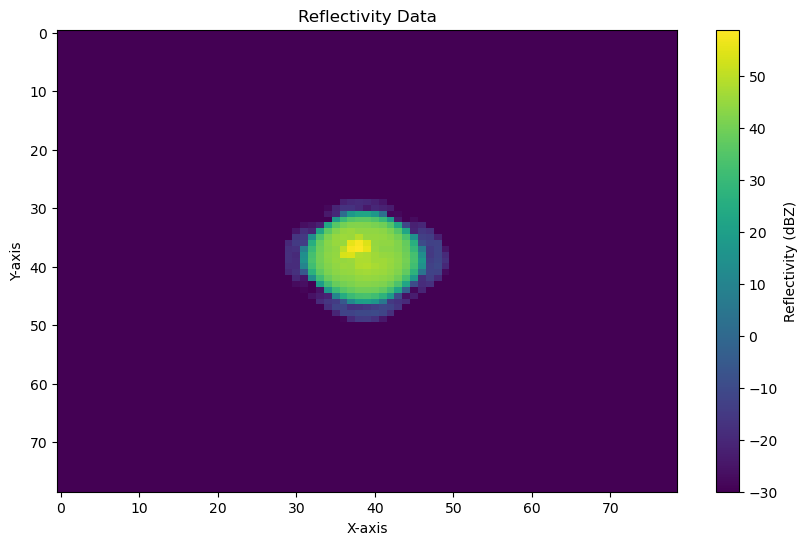

In [17]:
reflectivity_file = '/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/TEST_Multi_8_vars_996/000/reflectivity_000.npz'
reflectivity_data = np.load(reflectivity_file)
reflectivity = reflectivity_data['reflectivity']  # Cargar reflectividad
#print the shape of the reflectivity data
print("Reflectivity shape:", reflectivity.shape)
# Plot reflectivity data
plt.figure(figsize=(10, 6))
plt.imshow(reflectivity[:,:,5], cmap='viridis', aspect='auto')
plt.colorbar(label='Reflectivity (dBZ)')
plt.title('Reflectivity Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [22]:
summary_file = '/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/TEST_Multi_8_vars_996/000/summary_000.npz'
summary_data = np.load(summary_file)
print("Summary Data Keys:", summary_data.keys())

Summary Data Keys: KeysView(NpzFile '/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/TEST_Multi_8_vars_996/000/summary_000.npz' with keys: time, w_max, w_p90, w_mean_pos, t_max...)


In [ ]:
# Extract data from the summary file
time, w_max, w_p90, w_mean_pos, t_max, t_min, precip_max, precip_mean, ref_p90, ref_gt10, ref_gt50, cape, mucape, uh_1_1_5, uh_1_6 = [summary_data[key] for key in summary_data.files]
# print shape of each extracted data
print("Time shape:", time.shape)
print("W_max shape:", w_max.shape)
print("W_p90 shape:", w_p90.shape)
print("W_mean_pos shape:", w_mean_pos.shape)
print("T_max shape:", t_max.shape)
print("T_min shape:", t_min.shape)
print("Precip_max shape:", precip_max.shape)
print("Precip_mean shape:", precip_mean.shape)
print("Ref_p90 shape:", ref_p90.shape)
print("Ref_gt10 shape:", ref_gt10.shape)
print("Ref_gt50 shape:", ref_gt50.shape)
print("CAPE shape:", cape.shape)
print("MUCAPE shape:", mucape.shape)
print("UH_1_1_5 shape:", uh_1_1_5.shape)
print("UH_1_6 shape:", uh_1_6.shape)

Time shape: ()
W_max shape: (49,)
W_p90 shape: (49,)
W_mean_pos shape: (49,)
T_max shape: (49,)
T_min shape: (49,)
Precip_max shape: (49,)
Precip_mean shape: (49,)
Ref_p90 shape: (49,)
Ref_gt10 shape: (49,)
Ref_gt50 shape: (49,)
CAPE shape: ()
MUCAPE shape: ()
UH_1_1_5 shape: (49,)
UH_1_6 shape: (49,)


In [37]:
time

array(0.)

Text(0.5, 1.0, 'UH 1-6')

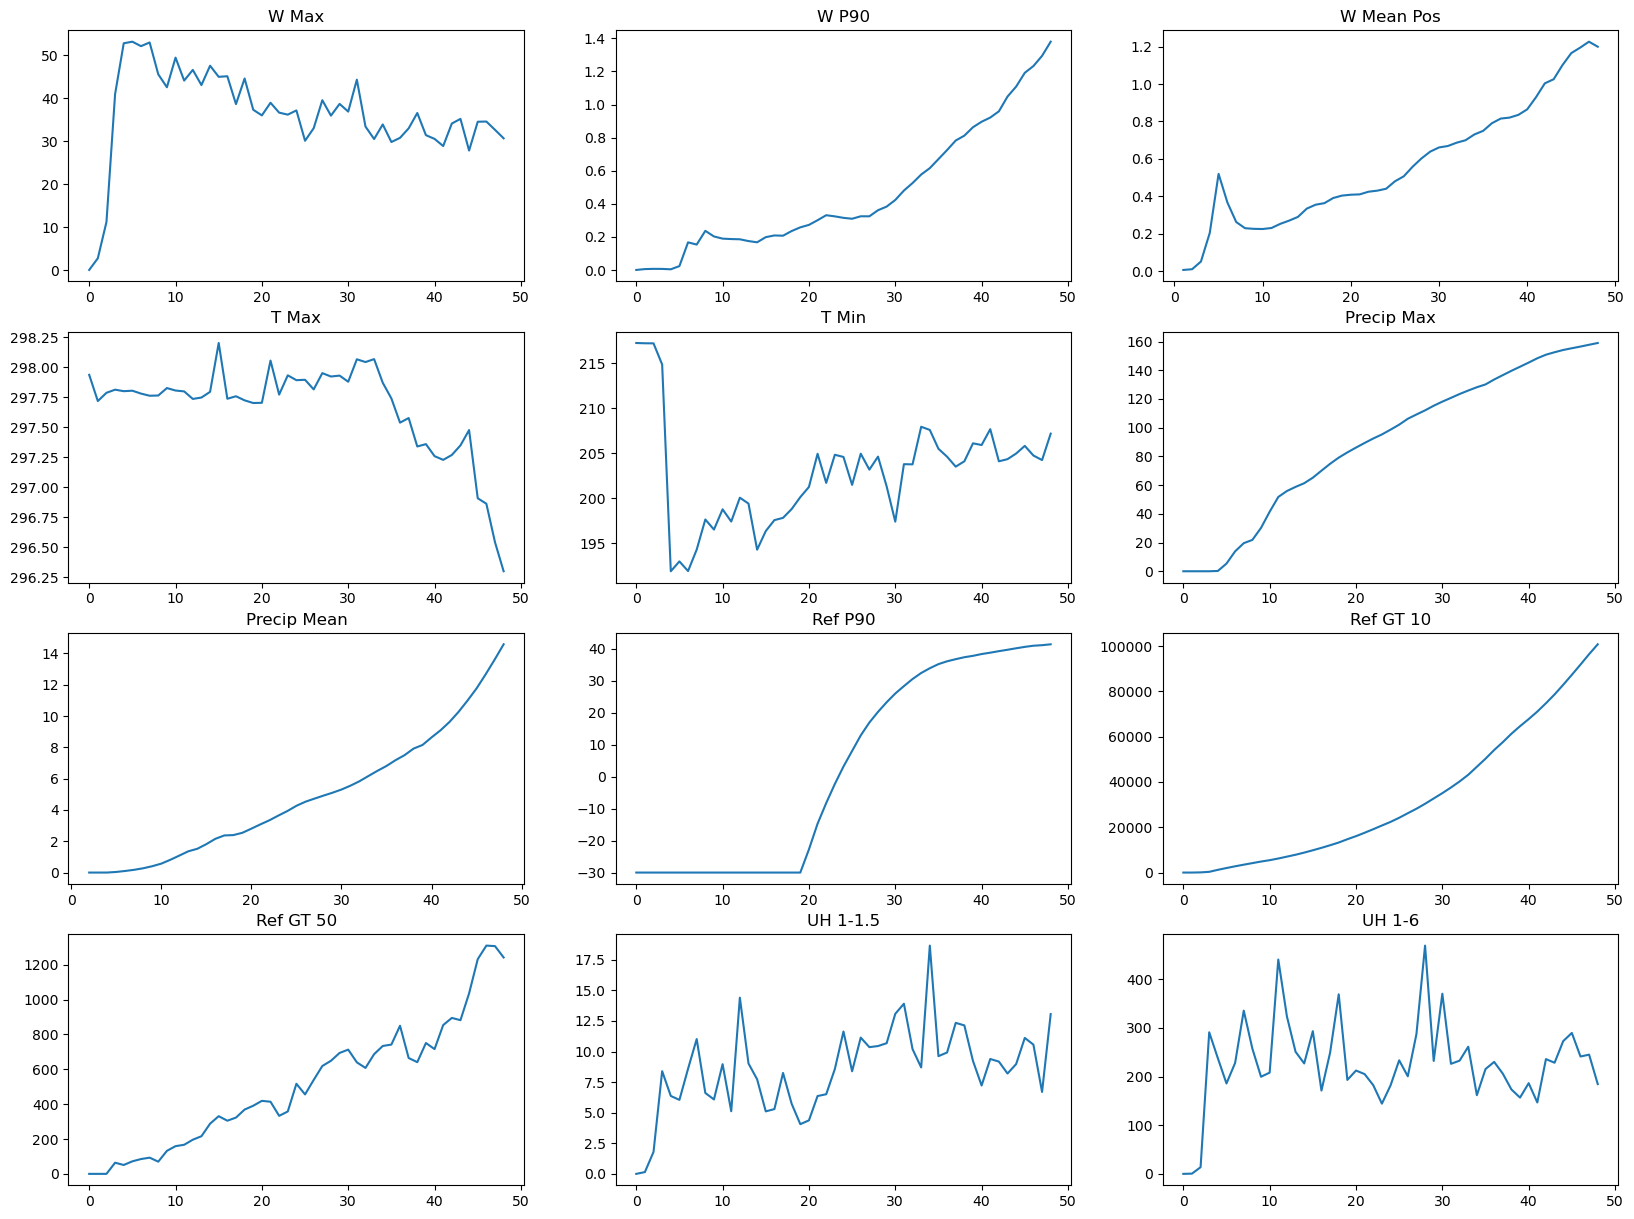

In [38]:
#plot time seris of all variables in different subplots
fig, axs = plt.subplots(4, 3, figsize=(20, 15))
axs = axs.flatten()
axs[0].plot( w_max, label='W Max')
axs[0].set_title('W Max')
axs[1].plot( w_p90, label='W P90')
axs[1].set_title('W P90')
axs[2].plot( w_mean_pos, label='W Mean Pos')
axs[2].set_title('W Mean Pos') 
axs[3].plot( t_max, label='T Max')
axs[3].set_title('T Max')
axs[4].plot( t_min, label='T Min')
axs[4].set_title('T Min')
axs[5].plot( precip_max, label='Precip Max')
axs[5].set_title('Precip Max')
axs[6].plot( precip_mean, label='Precip Mean')
axs[6].set_title('Precip Mean')
axs[7].plot( ref_p90, label='Ref P90')
axs[7].set_title('Ref P90')
axs[8].plot( ref_gt10, label='Ref GT 10')
axs[8].set_title('Ref GT 10')
axs[9].plot( ref_gt50, label='Ref GT 50')
axs[9].set_title('Ref GT 50')
axs[10].plot( uh_1_1_5, label='UH 1-1.5')
axs[10].set_title('UH 1-1.5')
axs[11].plot( uh_1_6, label='UH 1-6')
axs[11].set_title('UH 1-6')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import os
# Set the path to the data root and CSV file
data_root = "/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/TEST_Multi_8_vars_996"
csv_path  = "/home/jorge.gacitua/salidas/Sensitivity_Experiments/sampling_batch_1000_8_variables.csv"
# read the value in the 4th column of the CSV file
with open(csv_path, 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    param_values1 = [float(row[0]) for row in reader]

with open(csv_path, 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    param_values2 = [float(row[1]) for row in reader]

with open(csv_path, 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    param_values3 = [float(row[2]) for row in reader]

with open(csv_path, 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    param_values4 = [float(row[3]) for row in reader]

with open(csv_path, 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    param_values5 = [float(row[4]) for row in reader]

with open(csv_path, 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    param_values6 = [float(row[5]) for row in reader]

with open(csv_path, 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    param_values7 = [float(row[6]) for row in reader]
    
with open(csv_path, 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    param_values8 = [float(row[7]) for row in reader]

cape_values = []
for i in np.arange(len(param_values4)):
    expid = f"{i:03d}"
    exp_dir = os.path.join(data_root, expid)
    summary_file = os.path.join(exp_dir, f"summary_{expid}.npz")
    #print(summary_file)
    if not os.path.exists(summary_file):
        print(f"Summary file for experiment {expid} does not exist.")
        cape_values.append(np.nan)  # Append NaN if the file does not exist
        continue
    cape = np.load(summary_file)['cape']
    #print(f"Experiment {expid}: CAPE = {cape}")
    cape_values.append(cape)


Summary file for experiment 103 does not exist.
Summary file for experiment 996 does not exist.
Summary file for experiment 997 does not exist.
Summary file for experiment 998 does not exist.
Summary file for experiment 999 does not exist.


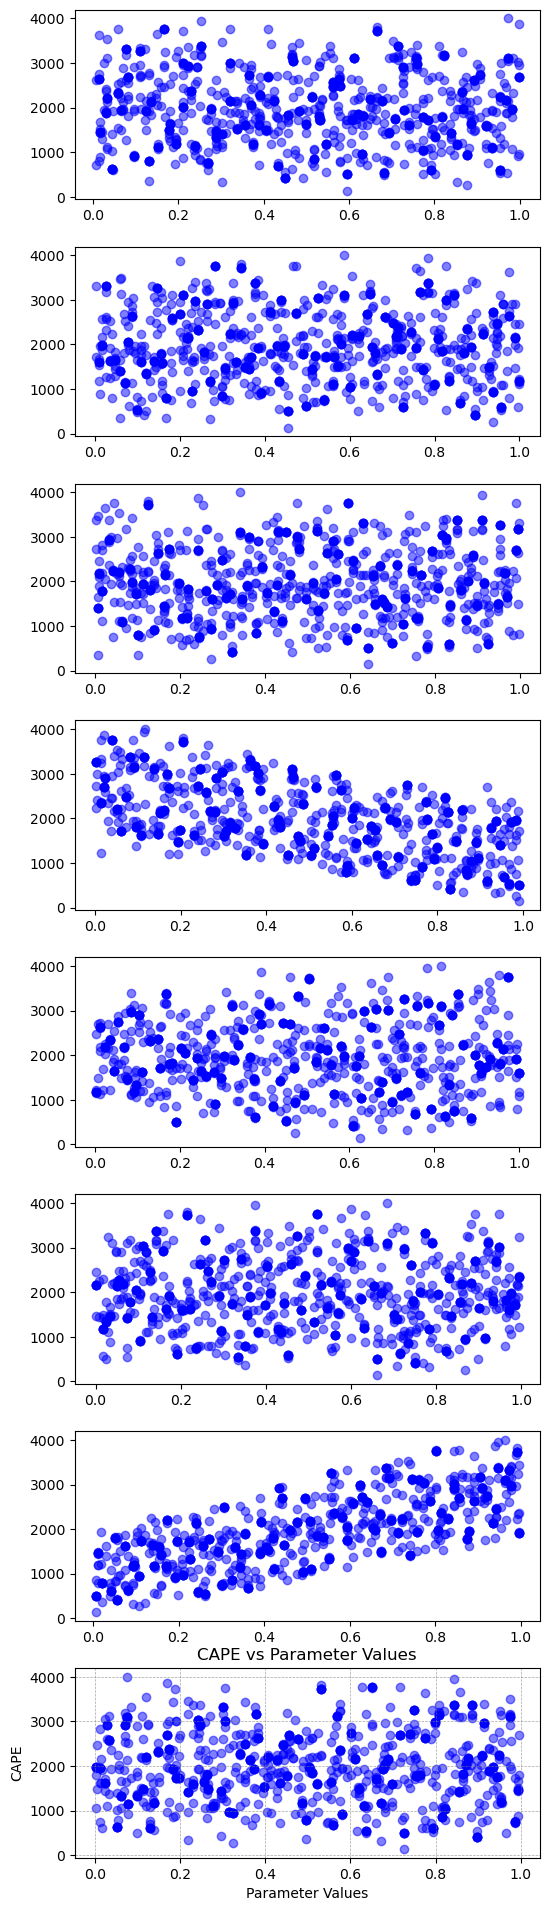

In [5]:
# Plot the parameter values against the CAPE values
fig, axes = plt.subplots(8, 1, figsize=(6, 24), 
                         sharex=False, sharey=False, 
                         gridspec_kw={'hspace': 0.25, 'wspace': 0.1})

axes[0].scatter(param_values1, cape_values, color='blue', alpha=0.5)
axes[1].scatter(param_values2, cape_values, color='blue', alpha=0.5)
axes[2].scatter(param_values3, cape_values, color='blue', alpha=0.5)
axes[3].scatter(param_values4, cape_values, color='blue', alpha=0.5)
axes[4].scatter(param_values5, cape_values, color='blue', alpha=0.5)
axes[5].scatter(param_values6, cape_values, color='blue', alpha=0.5)
axes[6].scatter(param_values7, cape_values, color='blue', alpha=0.5)
axes[7].scatter(param_values8, cape_values, color='blue', alpha=0.5)

plt.title('CAPE vs Parameter Values')
plt.xlabel('Parameter Values')
plt.ylabel('CAPE')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.7, color='gray')